In [1]:
from saltpy.agapito import SonarPy, SonarPlots, SonarPyVista, SonarDXF #!!! change to .public and test
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import re

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [2]:
## Single Cavern Processing, LWT

# Year as a float
year = 2025 + (7-1) / 12 + 20/365

# Location in WGS84 (X,Y,Z)
lat  = 30.0201245
long = -93.3378863
elev = 1
surveyxyzWGS84 = (long, lat, elev)

# Desired Coordinate Reference System (X,Y,Z)
crs = 'EPSG:3452'
x,y,z = 2646517.83, 558344.73, 3
surveyxyz = (x,y,z)

# Offset in Cartesian Space of the Desired CRS of the 
#    well bore at the top of the sonar survey
dx, dy, dz = 3,2,1

# Set up SonarPy object
sp = SonarPy(surveyxyz=surveyxyz, # x,y,z of well head
             surveyxyzWGS84=surveyxyzWGS84, # WGS84 xyz of wellhead, for finding correct UTM Zone
             crs=crs,
             year=year)
    
print('MagDec:', sp.magdec)

dflwt = sp.open_lwt('./data/example_lwt.lwt')
dfT = sp.lwt_df_to_dfT(dflwt)
xyz = sp.dfT_to_xyz_delta_points(dfT)
xyzUTM, xyzCRS = sp.generate_gdf(xyz, wb_delta=(dx,dy,dz)) #no wb_delta

MagDec: 0.4684135817814291


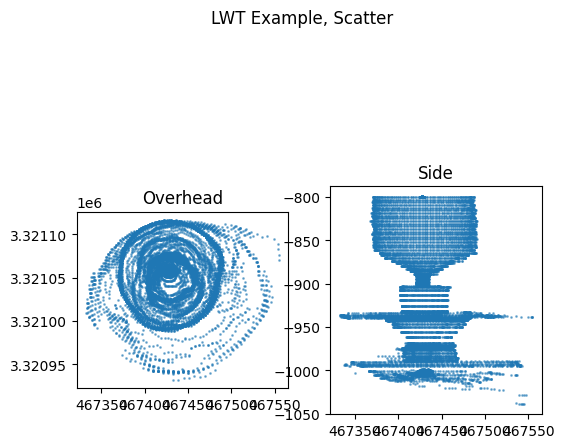

In [3]:
#Sonar Shot Points Plot
fig, ax = plt.subplots(1, 2, figsize=(6,6))

#Left, Top Down
ax[0].set_title("Overhead")
xyzUTM.plot(ax=ax[0], markersize=1, alpha=0.5)
ax[0].set_aspect('equal')

#Right, Side View From South
ax[1].set_title("Side")
xyza = xyzUTM[['x','y','z']].values
ax[1].scatter(xyza[:,0], xyza[:,2], marker='o', s=1, alpha=0.5)
ax[1].set_aspect('equal')

fig.suptitle('LWT Example, Scatter')
plt.show()

In [4]:
xyzUTM.head()

,depth,tilt,range,vos,cAzi,r,cAziN,mAzi,mInc,dx,dy,dz,x,y,z,geometry
0,2627.0,0.0,49.8,6014.0,0.0000,0.0,0.468414,89.531586,90.0,0.9144,0.6096,0.3048,467427.618928,3.321059e+06,-799.490374,POINT Z (467427.619 3321058.856 -799.490)
1,2627.0,0.0,49.8,6014.0,2.8125,0.0,3.280914,86.719086,90.0,0.9144,0.6096,0.3048,467427.618928,3.321059e+06,-799.490374,POINT Z (467427.619 3321058.856 -799.490)
2,2627.0,0.0,49.8,6014.0,5.6250,0.0,6.093414,83.906586,90.0,0.9144,0.6096,0.3048,467427.618928,3.321059e+06,-799.490374,POINT Z (467427.619 3321058.856 -799.490)
3,2627.0,0.0,49.8,6014.0,8.4375,0.0,8.905914,81.094086,90.0,0.9144,0.6096,0.3048,467427.618928,3.321059e+06,-799.490374,POINT Z (467427.619 3321058.856 -799.490)
4,2627.0,0.0,49.8,6014.0,11.2500,0.0,11.718414,78.281586,90.0,0.9144,0.6096,0.3048,467427.618928,3.321059e+06,-799.490374,POINT Z (467427.619 3321058.856 -799.490)


In [5]:
# Flodim 
## DimCav export of DMV

In [6]:
lat, long = 30.0161506,-93.3387168
elev = 1
surveyxyzWGS84 = (long, lat, elev)

# Desired Coordinate Reference System (X,Y,Z)
crs = 'EPSG:3452'
x, y, z = 2646201.88, 556917.16, 3
surveyxyz = (x,y,z)

year = 2023 + (7-1/12) + 23/365

# Offset in Cartesian Space of the Desired CRS of the 
#    well bore at the top of the sonar survey
dx, dy, dz = 4, 3, 2

# Set up SonarPy object
sp = SonarPy(surveyxyz=surveyxyz, # x,y,z of well head
             surveyxyzWGS84=surveyxyzWGS84, # WGS84 xyz of wellhead, for finding correct UTM Zone
             crs=crs,
             year=year)
    
print('MagDec:', sp.magdec)

dfT = sp.dmv_exported_lwt_to_dfT('./data/example_dmv_export.csv')
xyz = sp.dfT_to_xyz_delta_points(dfT)
xyzUTM2, xyzCRS2 = sp.generate_gdf(xyz, wb_delta=(dx,dy,dz)) #no wb_delta

MagDec: -0.01275039423270352


In [7]:
dfT

,depth,tilt,vos,cAzi,r,cAziN,mAzi,mInc
0,2515.1,0.0,5934.7,0.0,162.2,-0.01275,90.01275,90.0
1,2515.1,0.0,5934.7,3.0,162.4,2.98725,87.01275,90.0
2,2515.1,0.0,5934.7,6.0,159.0,5.98725,84.01275,90.0
3,2515.1,0.0,5934.7,9.0,162.3,8.98725,81.01275,90.0
4,2515.1,0.0,5934.7,12.0,162.0,11.98725,78.01275,90.0
...,...,...,...,...,...,...,...,...
22195,3089.2,0.0,5959.0,345.0,27.5,344.98725,105.01275,90.0
22196,3089.2,0.0,5959.0,348.0,27.8,347.98725,102.01275,90.0
22197,3089.2,0.0,5959.0,351.0,28.1,350.98725,99.01275,90.0
22198,3089.2,0.0,5959.0,354.0,28.4,353.98725,96.01275,90.0


In [8]:
# Process Wireframe
lines = SonarDXF.process_lines(xyzUTM2)
lines = gpd.GeoDataFrame(lines, geometry='geometry', crs=xyzUTM2.crs) #Delete this line later, public version fixed

NameError: name 'np' is not defined

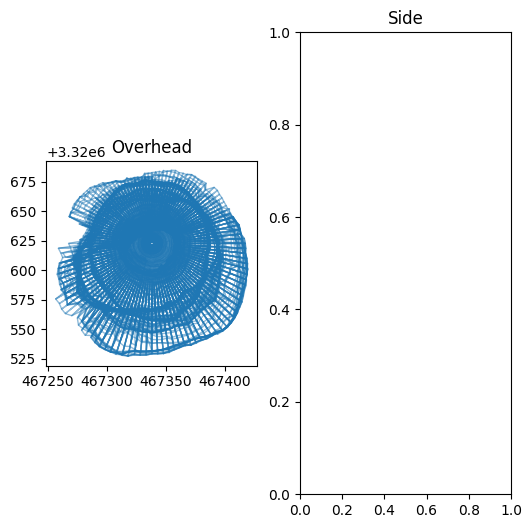

In [9]:
#Sonar Shot Points Plot
fig, ax = plt.subplots(1, 2, figsize=(6,6))

#Left, Top Down
ax[0].set_title("Overhead")
lines.plot(ax=ax[0], lw=1, alpha=0.5)
ax[0].set_aspect('equal')

#Right, Side View From South
ax[1].set_title("Side")
xz_l = [np.array([[l[0], l[2]]  for l in geom.coords[:]]) for geom in lines.geometry.values]

# lc = LineCollection(xz_l, alpha=0.5, linewidths=1)
# ax[1].add_collection(LineCollection(xz_l, alpha=0.5, linewidths=1))
for xz in xz_l:
    a = np.array(xz)
    ax[1].plot(a[:,0], a[:,1], color='tab:blue', alpha=0.5, lw=1)
# ax[1].autoscale()
ax[1].set_aspect('equal')


fig.suptitle('DMV Example, Wireframe')
plt.show()

In [ ]:
for xz in xz_l:
    a = np.array(xz)
    if a[:,0].min() < 267338:
        print(a[:,0].min(),a[:,0].max())
        print(a[:,1].min(),a[:,1].max())

In [ ]:
## Delete this in final
def dat_to_dfT(path):
    '''
    Opens a SOCON DAT file directly and exports a dfT
    # start of horizontal sections
    > end of horizontal section
    < end of vertical section
    @ end of volume section
    '''
    
    with open(path, 'r') as f:
        lines = f.readlines()

    # Seperate Horizontal and Vertical Sections
    clines = [x.replace('\n','') for x in lines]
    pattern = r'^[+-]?\d*\.?\d+$'
    altlines = [[i,x] for i,x in enumerate(clines) if not re.match(pattern, x)]
    altn = [x[0] for x in altlines]
    start, stop = [i for i,x in altlines if x in ['#','<']]
    clplines = [x for x in clines[start + 1 : stop] if x != '>']
    data = np.array(clplines)
    data = data.astype(float)
    
    # Seperate Data Types
    depths = data[::3]
    radius = data[1::3]
    azi = data[2::3]

    dfT = pd.DataFrame({'depth':depths, 'r':radius, 'cAzi':azi})
    dfT['tilt'] = 0
    
    return dfT



In [ ]:
lat, long = 30.0161506, -93.3387168
elev = 1
surveyxyzWGS84 = (long, lat, elev)

# Desired Coordinate Reference System (X,Y,Z)
crs = 'EPSG:3452'
x, y, z = 2646201.88, 556917.16, 3
surveyxyz = (x,y,z)

year = 2025 + (7-1/12) + 23/365

# Offset in Cartesian Space of the Desired CRS of the 
#    well bore at the top of the sonar survey
dx, dy, dz = 5, 4, 3

# Set up SonarPy object
sp = SonarPy(surveyxyz=surveyxyz, # x,y,z of well head
             surveyxyzWGS84=surveyxyzWGS84, # WGS84 xyz of wellhead, for finding correct UTM Zone
             crs=crs,
             year=year)
    
print('MagDec:', sp.magdec)

path = r"C:\scipts\1138-01\Sonar\7B\PPG 7B_2011-2023 sonars\PPG 7B_2023-02\feb 2023 ppg 7.dat"

dfT = dat_to_dfT(path)

xyz = sp.dfT_to_xyz_delta_points(dfT)
xyzUTM3, xyzCRS3 = sp.generate_gdf(xyz, wb_delta=(dx,dy,dz)) #no wb_delta

In [ ]:
# Delete this and fix imports in FINAL
import pyvista as pv
from stl import mesh
import pymeshfix as mf

def build_horizontal_shots(data, sort_by="cAzi"):
    """
    Builds a 3D STL-style mesh from sonar scan layers.

    !! Note: The function assumes consistent ring-like ordering between layers
    for valid surface stitching. Each layer must represent a distinct scan ring.

    Parameters
    ----------
    data : GeoDataFrame or list of GeoDataFrames
        Input sonar layer(s), each with x, y, z, and a sort_by column.
    sort_by : str, default='cAzi'
        Field to sort points within each layer (preserves ring structure).

    Returns
    -------
    vertices : np.ndarray
        Combined point coordinates (N x 3).
    faces : list of lists
        Triangle faces in [3, i1, i2, i3] format.
    """
    if isinstance(data, list):
        layers = data

    elif isinstance(data, gpd.GeoDataFrame):
        gdf = data.copy()
        unique_depths = gdf["depth"].unique()

        if len(unique_depths) > 1:
            grouped = gdf.groupby("depth")
            layers = [grouped.get_group(k) for k in sorted(grouped.groups.keys())]
            print(f"Grouped by 'depth' into {len(layers)} layers.")
        else:
            print("All depths equal — splitting into 2 layers by z.")
            gdf = gdf.sort_values("z").reset_index(drop=True)
            mid = len(gdf) // 2
            gdf.loc[:mid - 1, "layer_id"] = 1
            gdf.loc[mid:, "layer_id"] = 2
            grouped = gdf.groupby("layer_id")
            layers = [grouped.get_group(k) for k in sorted(grouped.groups.keys())]
            print("Assigned 'layer_id' based on z splitting.")

    else:
        raise TypeError("Input must be a GeoDataFrame or list of GeoDataFrames.")

    # Sort and trim all layers to match size
    sorted_layers = []
    min_len = min(len(layer) for layer in layers)
    for layer in layers:
        layer = layer.sort_values(sort_by).reset_index(drop=True)
        layer = layer.iloc[:min_len]
        coords = layer[["x", "y", "z"]].to_numpy()
        sorted_layers.append(coords)

    # Stack vertices
    vertices = np.vstack(sorted_layers)
    n_layers = len(sorted_layers)
    points_per_layer = sorted_layers[0].shape[0]

    # Build triangle faces
    faces = []
    for i in range(n_layers - 1):
        top = i * points_per_layer
        bottom = (i + 1) * points_per_layer
        for j in range(points_per_layer):
            next_j = (j + 1) % points_per_layer
            a, b = top + j, top + next_j
            c, d = bottom + j, bottom + next_j
            faces.append([a, b, c])
            faces.append([b, d, c])

    return vertices, faces

def build_endcap(layer_df):
    """
    Build a 3D mesh for a single sonar scan layer using 2D Delaunay triangulation in (x, y).

    Parameters
    ----------
    layer_df : pandas.DataFrame or GeoDataFrame
        DataFrame containing sonar points from a single horizontal layer, with columns 'x', 'y', and 'z'.

    Returns
    -------
    vertices : ndarray of shape (N, 3)
        3D coordinates of the mesh vertices.
    faces : list of list of int
        Triangle face indices as index triplets into the vertices array.
    """
    points_2d = layer_df[["x", "y"]].to_numpy()
    points_3d = layer_df[["x", "y", "z"]].to_numpy()

    tri = Delaunay(points_2d)
    faces = tri.simplices.tolist()

    return points_3d, faces


def combine_mesh_parts(parts, filename="combined_mesh.stl"):
    """
    Combine multiple mesh parts (each with vertices and faces) into a single STL mesh file.

    Parameters
    ----------
    parts : list of tuple (ndarray, list of list of int)
        List of mesh parts, where each element is a tuple of:
        - vertices : ndarray of shape (N, 3)
        - faces : list of index triplets into the vertices array

    filename : str, optional
        Output filename for the combined STL mesh. Default is 'combined_mesh.stl'.
    """
    all_vertices = []
    all_faces = []

    vertex_offset = 0
    for vertices, faces in parts:
        all_vertices.append(vertices)
        # Shift face indices by current vertex offset
        shifted_faces = [[i + vertex_offset for i in face] for face in faces]
        all_faces.extend(shifted_faces)
        vertex_offset += len(vertices)

    # Stack everything
    vertices = np.vstack(all_vertices)
    faces = all_faces

    # Convert to triangle array
    triangles = np.zeros((len(faces), 3, 3), dtype=np.float32)
    for i, (a, b, c) in enumerate(faces):
        triangles[i][0] = vertices[a]
        triangles[i][1] = vertices[b]
        triangles[i][2] = vertices[c]

    # Create and save mesh
    your_mesh = mesh.Mesh(np.zeros(triangles.shape[0], dtype=mesh.Mesh.dtype))
    for i in range(triangles.shape[0]):
        your_mesh.vectors[i] = triangles[i]

    your_mesh.save(filename)
    print(f"Combined mesh saved to: {filename}")

In [ ]:
h_vertices, h_faces = build_horizontal_shots(xyzUTM3)
combine_mesh_parts(
    parts=[
        (h_vertices, h_faces),
    ],
    filename="full_cave_mesh.stl"
)

mesh = pv.read("full_cave_mesh.stl")
mesh.plot()

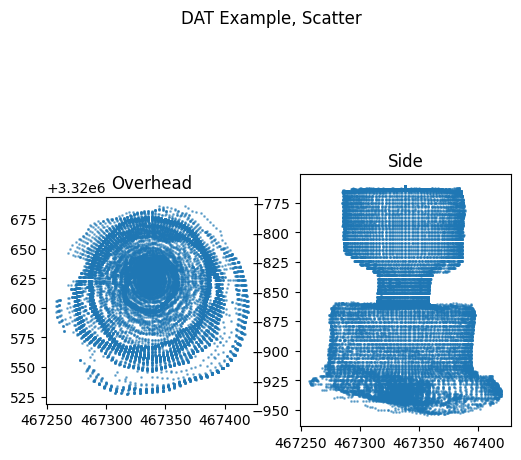

In [140]:
#Sonar Shot Points Plot
fig, ax = plt.subplots(1, 2, figsize=(6,6))

#Left, Top Down
ax[0].set_title("Overhead")
xyzUTM3.plot(ax=ax[0], markersize=1, alpha=0.5)
ax[0].set_aspect('equal')

#Right, Side View From South
ax[1].set_title("Side")
xyza = xyzUTM3[['x','y','z']].values
ax[1].scatter(xyza[:,0], xyza[:,2], marker='o', s=1, alpha=0.5)
ax[1].set_aspect('equal')

fig.suptitle('DAT Example, Scatter')
plt.show()

In [92]:
# [np.array([[l[0], l[2]]  for l in geom.coords[:]]) for geom in lines.geometry.values]
geom = lines.geometry.values[10]
np.array(geom.coords[:])

array([[ 4.67427759e+05,  3.32107603e+06, -8.24788774e+02],
       [ 4.67428611e+05,  3.32107615e+06, -8.24788774e+02],
       [ 4.67429475e+05,  3.32107624e+06, -8.24788774e+02],
       [ 4.67430350e+05,  3.32107629e+06, -8.24788774e+02],
       [ 4.67431170e+05,  3.32107598e+06, -8.24788774e+02],
       [ 4.67432045e+05,  3.32107593e+06, -8.24788774e+02],
       [ 4.67432831e+05,  3.32107555e+06, -8.24788774e+02],
       [ 4.67433644e+05,  3.32107527e+06, -8.24788774e+02],
       [ 4.67434503e+05,  3.32107510e+06, -8.24788774e+02],
       [ 4.67435292e+05,  3.32107474e+06, -8.24788774e+02],
       [ 4.67436062e+05,  3.32107435e+06, -8.24788774e+02],
       [ 4.67436812e+05,  3.32107391e+06, -8.24788774e+02],
       [ 4.67437540e+05,  3.32107344e+06, -8.24788774e+02],
       [ 4.67438524e+05,  3.32107331e+06, -8.24788774e+02],
       [ 4.67439125e+05,  3.32107264e+06, -8.24788774e+02],
       [ 4.67439995e+05,  3.32107229e+06, -8.24788774e+02],
       [ 4.67440864e+05,  3.32107189e+06

In [87]:
import

depth  inc  \
0    2627.0  0.0   
1    2628.0  0.0   
2    2630.0  0.0   
3    2640.0  0.0   
4    2650.0  0.0   
..      ...  ...   
323  3270.0  NaN   
324  3270.0  NaN   
325  3270.0  NaN   
326  3270.0  NaN   
327  3270.0  NaN   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [12]:
import numpy as np
a = np.array([[0,0,0],
             [0,1,0],
             [0,0,0]])
np.pad(a, pad_width=1)

array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]])

In [ ]:
scipy.ndimage.binary_dilation(a, 
                                                iterations=1, 
                                                structure=struct)